# Базовое решение Задачи  "Спрос на бронирование отелей"

Данные содержат сведения о спросе на отели. Каждое наблюдение представляет собой бронирование отеля. Набор данных учитывает бронирования, которые должны прибыть в период с 1 июля 2015 года по 31 августа 2017 года, включая фактически поступившие и отмененные бронирования.


- Тренировочный набор  **44 638 строк**.


hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment


отель, бронирование отменено (0 или 1), время бронирования, дата заезда на год, дата заезда на месяц, дата заезда на неделю, количество дней заезда на месяц, количество ночей заезда на выходные, количество ночей заезда на неделю, взрослые, дети, младенцы, питание, страна, сегмент рынка

distribution_channel, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, reserved_room_type, assigned_room_type, booking_changes, deposit_type, days_in_waiting_list, customer_type,adr, required_c

канал распространения_, это_повторный_гость предыдущие отмены_заказа, предыдущие бронирования не отменены, забронированный_тип_комнаты, назначенный_тип_комнаиы, изменения в бронировании, тип депозита, список ожидающих дней, тип клиента

required_car_parking_spaces,total_of_special_requests,reservation_status_date

требуемые_места_для_парковки,общее количество_специальных_запросов,дата резервирования

## Считывание данных

In [1]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

In [29]:
# Считываем  данные
train = pd.read_csv("train_final.csv")

print(f"Размерность: {train.shape}")

Размерность: (44638, 29)


In [30]:
# Посмотрим как выглядят данные
train.head(15)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,3,2016,February,7,12,0,2,2,...,E,F,0,No Deposit,0,Transient,81.00,1,0,2016-02-14
1,City Hotel,1,50,2016,November,47,18,1,2,2,...,A,A,0,No Deposit,0,Transient,93.60,0,2,2016-10-09
2,City Hotel,0,14,2015,September,37,7,1,5,2,...,F,F,0,No Deposit,0,Contract,166.00,0,3,2015-09-13
3,City Hotel,0,18,2015,December,50,6,2,0,2,...,A,A,0,No Deposit,0,Transient,107.00,0,0,2015-12-08
4,City Hotel,1,263,2016,September,40,29,2,4,2,...,A,A,0,No Deposit,0,Transient,100.30,0,0,2016-01-18
5,Resort Hotel,0,45,2016,March,10,1,0,5,2,...,E,G,1,No Deposit,0,Transient,106.00,0,1,2016-03-06
6,Resort Hotel,0,131,2015,December,52,22,2,5,2,...,D,D,1,No Deposit,0,Transient-Party,72.14,0,1,2015-12-29
7,Resort Hotel,0,152,2017,July,28,11,2,5,2,...,D,D,0,No Deposit,0,Transient-Party,194.86,0,2,2017-07-18
8,City Hotel,0,102,2015,October,42,16,0,2,2,...,A,E,0,No Deposit,0,Transient-Party,109.00,0,0,2015-10-18
9,Resort Hotel,0,4,2017,April,17,26,0,2,1,...,A,A,0,No Deposit,0,Transient,45.00,0,0,2017-04-28


## Исследование данных

Прежде чем переходить к непосредственному построению модели, в первую очередь необходимо исследовать имеющихся у вас набор данных:
1. Какую задачу вы решаете (классификация, регрессия) и какая переменная является целевой?
2. Сколько переменных в данных и какого они типа?
3. Имеются ли в данных пропуски?

In [31]:
print("Количество пропущенных значений в наборе данных")
print(train.isna().sum())


Количество пропущенных значений в наборе данных
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_par

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44638 entries, 0 to 44637
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           44638 non-null  object 
 1   is_canceled                     44638 non-null  int64  
 2   lead_time                       44638 non-null  int64  
 3   arrival_date_year               44638 non-null  int64  
 4   arrival_date_month              44638 non-null  object 
 5   arrival_date_week_number        44638 non-null  int64  
 6   arrival_date_day_of_month       44638 non-null  int64  
 7   stays_in_weekend_nights         44638 non-null  int64  
 8   stays_in_week_nights            44638 non-null  int64  
 9   adults                          44638 non-null  int64  
 10  children                        44638 non-null  float64
 11  babies                          44638 non-null  int64  
 12  meal                            

**Проверим баланс классов.**

В задаче классификации данные называются несбалансированными (Imbalanced Data), если в обучающей выборке доли объектов разных классов существенно различаются, также говорят, что «классы не сбалансированы».

Рассмотрим признак **is_canceled** (бронирование отменено (0 или 1))

In [33]:
train['is_canceled'].value_counts()

is_canceled
0    31354
1    13284
Name: count, dtype: int64

C:\Users\HappyUser\AppData\Local\Temp\ipykernel_3312\3680111022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=y_data, palette='hls')


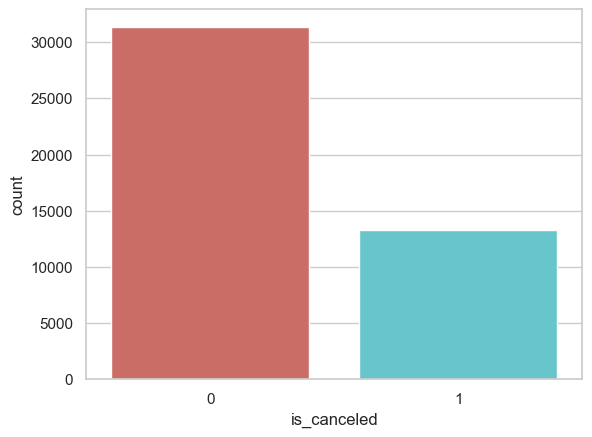

In [34]:
sns.set_theme(style="white")
sns.set_theme(style="whitegrid", color_codes=True)
y_data = pd.DataFrame(train['is_canceled'])
sns.countplot(x='is_canceled', data=y_data, palette='hls')
plt.show()

## Предобработка данных

Исходя из анализа данных, можно сделать выводы:
- в данных пропусков нет
- в данных имеются категориальные признаки
- в задаче решается задача бинарной классификации по признаку **is_canceled**

### Кодирование признаков

**Категориальные** признаки называют по-разному: **факторными**, **номинальными**. Их значения определяют факт принадлежности к какой-то категории.

Примеры таких признаков: пол, страна проживания, номер группы, категория товаров и т.п. Ясно, что для компьютерной обработки вместо «понятного для человека» значения (в случае страны — ‘Russia’, ‘GB’, ‘France’ и т.п.) хранят числа.

Существуют разные способы кодирования категориальных признаков:
1. Простейший кодировщий `sklearn.preprocessing.LabelEncoder`, который каждой категории сопоставляет некоторое целое число (собственно, номер категории).

Например, существует категориальная переменная:

```markdown
   |  Статус вакцинации |
---|--------------------|
1  |    Вакцинирован    |
2  |  Не вакцинирован   |
3  |     Мед отвод      |
4  |     Мед отвод      |
5  |  Не вакцинирован   |
6  |    Вакцинирован    |

```

После применения кодирования с помощью LabelEncoder получаем следущее (собственно он закодировал наши категориальные переменные: Вакцинирован = 0, Не вакцинирован = 1, Мед отвод = 2):

```markdown
   |  Статус вакцинации |
---|--------------------|
1  |         0          |
2  |         1          |
3  |         2          |
4  |         2          |
5  |         1          |
6  |         0          |

```

2. Метод библиотеки Pandas:

`pandas.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)[source]`

Например, существует категориальная переменная:

```markdown
   |  Статус вакцинации |
---|--------------------|
1  |    Вакцинирован    |
2  |  Не вакцинирован   |
3  |     Мед отвод      |
4  |     Мед отвод      |
5  |  Не вакцинирован   |
6  |    Вакцинирован    |

```

Метод принимает категориальную переменную в качестве аргумента. Далее создает новую переменную для каждой категории, так что каждая фиктивная переменная содержит данные 1 или 0. 1 - указывает на наличие определенной категории и 0 - указывает на отсутствие этой категории.

```markdown
   | Статус вакцинации | Вакцинирован | Не вакцинирован | Мед отвод |
---|-------------------|--------------|-----------------|-----------|
1  |   Вакцинирован    |      1       |        0        |     0     |
2  | Не вакцинирован   |      0       |        1        |     0     |
3  |    Мед отвод      |      0       |        0        |     1     |
4  |    Мед отвод      |      0       |        0        |     1     |
5  | Не вакцинирован   |      0       |        1        |     0     |
6  |   Вакцинирован    |      1       |        0        |     0     |

```

3. Кодировщик библиотеки Sklearn `from sklearn.preprocessing import OneHotEncoder`.

По принципу работы действует точно также как get_dummies().

Основное отличие - это кодировщик, т.е. это некоторая модель которая обучилась на данных, запомнила словарь и т.д., дальше может быть с этими параметры применяться к другому набору данных, к новым данным например.

Get_dummies() - это просто метод класса, который по сути вы одноразово используете.

In [35]:
# Выбрем признаки, которые являются категориальными (строковыми)
train.loc[:, train.dtypes == object]


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status_date
0,Resort Hotel,February,BB,PRT,Direct,Direct,E,F,No Deposit,Transient,2016-02-14
1,City Hotel,November,BB,BEL,Online TA,TA/TO,A,A,No Deposit,Transient,2016-10-09
2,City Hotel,September,BB,ITA,Online TA,TA/TO,F,F,No Deposit,Contract,2015-09-13
3,City Hotel,December,BB,ESP,Online TA,TA/TO,A,A,No Deposit,Transient,2015-12-08
4,City Hotel,September,BB,DEU,Online TA,TA/TO,A,A,No Deposit,Transient,2016-01-18
...,...,...,...,...,...,...,...,...,...,...,...
44633,City Hotel,June,BB,JPN,Online TA,TA/TO,D,D,No Deposit,Transient,2017-06-28
44634,Resort Hotel,September,BB,GBR,Online TA,TA/TO,E,F,No Deposit,Transient,2015-10-03
44635,City Hotel,April,SC,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,2017-02-09
44636,City Hotel,September,HB,NOR,Offline TA/TO,TA/TO,A,A,No Deposit,Transient-Party,2016-09-12


Используем метод **drop()** библиотеки Pandas для удаления 4 категориальных признаков 'reservation_status_date', 'country', 'assigned_room_type', 'reserved_room_type' ("дата статуса бронирования", "страна", "назначенный тип_комнаты", "зарезервированный тип_комнаты"):

Цель метода — удаление нежелательных строк или столбцов из DataFrame. Часто используется для очистки данных, например, при удалении строк и столбцов с отсутствующими значениями или крайними значениями

In [36]:
train=train.drop(columns=['reservation_status_date', 'country', 'assigned_room_type', 'reserved_room_type'])
train.shape


(44638, 25)

In [37]:
cat_features = train.loc[:, train.dtypes == object].columns
cat_features # вывод списка категориальных признаков

Index(['hotel', 'arrival_date_month', 'meal', 'market_segment',
       'distribution_channel', 'deposit_type', 'customer_type'],
      dtype='object')

In [38]:
train['hotel'].value_counts()

hotel
City Hotel      29335
Resort Hotel    15303
Name: count, dtype: int64

In [39]:
train['market_segment'].value_counts()

market_segment
Online TA        21325
Offline TA/TO     9085
Groups            6868
Direct            4922
Corporate         2046
Complementary      308
Aviation            84
Name: count, dtype: int64

In [40]:
train['deposit_type'].value_counts()

deposit_type
No Deposit    40235
Non Refund     4339
Refundable       64
Name: count, dtype: int64

In [41]:
# Закодируем часть категориальных признаков с помощью LabelEncoder()
# а часть с помощью GetDummies()

from sklearn import preprocessing

# 1. Создадим модель кодировщика
label_encoder = preprocessing.LabelEncoder()

# 2. Обучение кодировщика: по сути тут создает словарь уникальных слов из переданного массива,
# соотносит для каждого слова число
label_encoder.fit(train['arrival_date_month'])

# на этом этапе по сути применяет полученный словарь в переданным данных (в данном случае мы передали столбец число)
train['arrival_date_month'] = label_encoder.transform(train['arrival_date_month'])


train.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,3,2016,3,7,12,0,2,2,...,0,0,0,0,No Deposit,0,Transient,81.0,1,0
1,City Hotel,1,50,2016,9,47,18,1,2,2,...,0,0,0,0,No Deposit,0,Transient,93.6,0,2
2,City Hotel,0,14,2015,11,37,7,1,5,2,...,0,0,0,0,No Deposit,0,Contract,166.0,0,3
3,City Hotel,0,18,2015,2,50,6,2,0,2,...,0,0,0,0,No Deposit,0,Transient,107.0,0,0
4,City Hotel,1,263,2016,11,40,29,2,4,2,...,0,0,0,0,No Deposit,0,Transient,100.3,0,0


In [42]:
label_encoder.classes_
#array(['April', 'August', 'December', 'February', 'January', 'July',_
#       'June', 'March', 'May', 'November', 'October', 'September'], dtype=object)

array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object)

In [43]:
categ = ['market_segment', 'customer_type', 'meal', 'distribution_channel']

# Encode Categorical Columns

for col in categ:

    # создание и обучение
    le = preprocessing.LabelEncoder()
    train[col] = le.fit_transform(train[col])



train.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,3,2016,3,7,12,0,2,2,...,0,0,0,0,No Deposit,0,2,81.0,1,0
1,City Hotel,1,50,2016,9,47,18,1,2,2,...,0,0,0,0,No Deposit,0,2,93.6,0,2
2,City Hotel,0,14,2015,11,37,7,1,5,2,...,0,0,0,0,No Deposit,0,0,166.0,0,3
3,City Hotel,0,18,2015,2,50,6,2,0,2,...,0,0,0,0,No Deposit,0,2,107.0,0,0
4,City Hotel,1,263,2016,11,40,29,2,4,2,...,0,0,0,0,No Deposit,0,2,100.3,0,0


In [44]:
# Попробуем другой вариант кодировщика
train = pd.get_dummies(train, columns=['hotel', 'market_segment', 'deposit_type'])

train.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,market_segment_0,market_segment_1,market_segment_2,market_segment_3,market_segment_4,market_segment_5,market_segment_6,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable
0,0,3,2016,3,7,12,0,2,2,0.0,...,False,False,False,True,False,False,False,True,False,False
1,1,50,2016,9,47,18,1,2,2,0.0,...,False,False,False,False,False,False,True,True,False,False
2,0,14,2015,11,37,7,1,5,2,2.0,...,False,False,False,False,False,False,True,True,False,False
3,0,18,2015,2,50,6,2,0,2,0.0,...,False,False,False,False,False,False,True,True,False,False
4,1,263,2016,11,40,29,2,4,2,0.0,...,False,False,False,False,False,False,True,True,False,False


In [45]:
train.dtypes

is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                  int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                int64
distribution_channel                int64
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
booking_changes                     int64
days_in_waiting_list                int64
customer_type                       int64
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests           int64
hotel_City Hotel                     bool
hotel_Resort Hotel                

## Обучение модели

Теперь наши данные готовы для обучения модели.

In [46]:
# Выделим вектор признаков и вектор ответов
X = train.drop(columns=['is_canceled'])
y = train['is_canceled']

Всего у нас получилось 33 признака.

In [47]:
print(f'X shape: {X.shape}')
print(f'Y shape: {y.shape}')

X shape: (44638, 33)
Y shape: (44638,)


Разделение на тестовую и обучающую выборки

In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [49]:
x_train.shape, x_test.shape

((31246, 33), (13392, 33))

In [50]:
y_train.shape, y_test.shape

((31246,), (13392,))

In [51]:
# Создадим модель логистической регрессии
model = LogisticRegression()

# обучение модели
model.fit(x_train, y_train)

# предсказание ответов для тестовой выборки
answers_pred = model.predict(x_test)

C:\Users\HappyUser\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# answers_pred - ответы которые вернула модель для X_test
# y_test - это правильные ответы для X_test
print(f'Accuracy: {"Аккуратность", accuracy_score(y_test, answers_pred)}')
print(f'Precision: {"Точность", precision_score(y_test, answers_pred)}')
print(f'Recall: {"Полнота", recall_score(y_test, answers_pred)}')

Accuracy: ('Аккуратность', 0.8033900836320191)
Precision: ('Точность', 0.7679194110809764)
Recall: ('Полнота', 0.49352589641434264)


In [53]:
from sklearn.metrics import confusion_matrix
print ("Confusion Matrix:\n",confusion_matrix(y_test, answers_pred))

Confusion Matrix:
 [[8777  599]
 [2034 1982]]


##### метка **accuracy_score** показывает долю правильных предсказаний


 **Confusion_Matrix** - матрица ошибок (матрица путаницы) - по диагаонали: правильно предсказанные объекты двух наших классов (8805+1909=10714),и в идеальном варианте все данные должны находиться только на диагонали ( если значения появляются не на диагонали- это ошибки). И чем больше таких значений, тем хуже модель справляется с поставленной
 задачей). По такой матрице можно увидеть, в каком классе мы больше всего не уверены.

In [54]:
# Построение матрицы ошибок
import numpy as np
from sklearn.metrics import confusion_matrix
y_true_1 = y_test
y_pred_1 = answers_pred
dc_mf_tn, dc_mf_fp, dc_mf_fn, dc_mf_tp = confusion_matrix(y_true_1, y_pred_1, labels = [0, 1]).ravel()
matrix1 = pd.DataFrame(np.array([dc_mf_tp, dc_mf_fn, dc_mf_fp, dc_mf_tn]).reshape(2, 2),
                  index=['Истинный класс +', 'Истинный класс -'],
                  columns=['Прогнозируемый класс +', 'Прогнозируемый класс -'])
matrix1

,Прогнозируемый класс +,Прогнозируемый класс -
Истинный класс +,1982,2034
Истинный класс -,599,8777


**ЗАДАНИЕ**

По имеющемуся датасету ***построить модель логистической регрессии*** для решения задачи бинарной классификации. В качестве результирующего признака выбрать, например, показатель, имеющий значения 0 и 1. Или выбрать таргетированную переменную и в зависимости от значений определить классы 0 и 1 (т.е. самсотоятельно закодировать значения этой переменной)  

***Оценить аккуратность, точность, полноту*** построенной модели. Проинтерпретировать результаты.

***Вычислить матрицу ошибок*** , проинтерпретировать полученные результаты.

In [27]:
train = pd.read_csv("train_final.csv")
print(f"Размерность данных: {train.shape}")
print(f"Пропуски:\n{train.isna().sum()}")
print(f"Типы данных:\n{train.dtypes}")

Размерность данных: (44638, 29)
Пропуски:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_s

In [28]:
train = train.drop(columns=['reservation_status_date', 'country', 'assigned_room_type', 'reserved_room_type'])

In [29]:
from sklearn.preprocessing import LabelEncoder
le_month = LabelEncoder()
train['arrival_date_month'] = le_month.fit_transform(train['arrival_date_month'])

# Список признаков для one-hot кодирования
ohe_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
train = pd.get_dummies(train, columns=ohe_cols, drop_first=False)

print(f"Размер после кодирования: {train.shape}")

Размер после кодирования: (44638, 44)


In [30]:
# Выделим бинарные признаки (полученные после one-hot)
from sklearn.preprocessing import StandardScaler
binary_cols = [col for col in train.columns if col.startswith(tuple(ohe_cols))]

# Числовые признаки, которые нужно масштабировать
num_cols = [col for col in train.select_dtypes(include=[np.number]).columns if col not in binary_cols and col != 'is_canceled']

scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])

In [31]:
X = train.drop(columns=['is_canceled'])
y = train['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (31246, 43), Test size: (13392, 43)


In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.8324
Precision: 0.8681
Recall: 0.5152
Confusion Matrix:
[[9095  312]
 [1932 2053]]


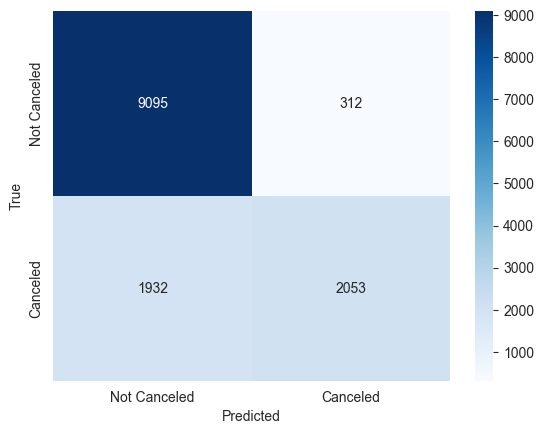

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Визуализация матрицы ошибок
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()